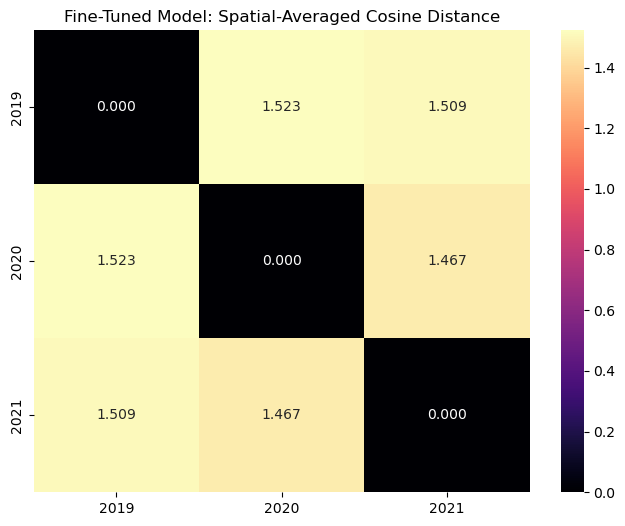

Variance explained by 2 components: 100.00%


In [6]:
import rasterio
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances
import seaborn as sns
import matplotlib.pyplot as plt

def get_pooled_embeddings(paths):
    pooled_vectors = []
    for path in paths:
        with rasterio.open(path) as src:
            # Read data: (Bands, Height, Width)
            data = src.read().astype('float32')
            
            # Global Average Pooling: Average across Height (axis 1) and Width (axis 2)
            # This collapses 12.5M features down to just the number of Bands
            vector = np.mean(data, axis=(1, 2)) 
            pooled_vectors.append(vector)
    return np.array(pooled_vectors)

# 1. Load and Pool
file_paths = ["2019-final.tif", "2020-final.tif", "2021-final.tif"]
X_pooled = get_pooled_embeddings(file_paths)

# 2. Scale and PCA
# With only ~64-128 bands, this is now much more stable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pooled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Calculate and Plot
dist_matrix = cosine_distances(X_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, fmt=".3f", cmap="magma",
            xticklabels=["2019", "2020", "2021"],
            yticklabels=["2019", "2020", "2021"])
plt.title("Fine-Tuned Model: Spatial-Averaged Cosine Distance")
plt.show()

print(f"Variance explained by 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")

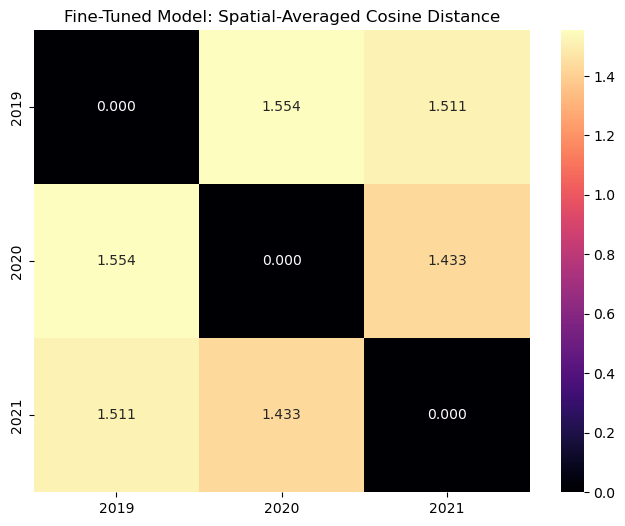

Variance explained by 2 components: 100.00%


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def get_pooled_embeddings(paths):
    pooled_vectors = []
    for path in paths:
        with rasterio.open(path) as src:
            # Read data: (Bands, Height, Width)
            data = src.read().astype('float32')
            
            # Global Average Pooling: Average across Height (axis 1) and Width (axis 2)
            # This collapses 12.5M features down to just the number of Bands
            vector = np.mean(data, axis=(1, 2)) 
            pooled_vectors.append(vector)
    return np.array(pooled_vectors)

# 1. Load and Pool
file_paths = ["2019-final-tiny.tif", "2020-final-tiny.tif", "2021-final-tiny.tif"]
X_pooled = get_pooled_embeddings(file_paths)

# 2. Scale and PCA
# With only ~64-128 bands, this is now much more stable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pooled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Calculate and Plot
dist_matrix = cosine_distances(X_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, fmt=".3f", cmap="magma",
            xticklabels=["2019", "2020", "2021"],
            yticklabels=["2019", "2020", "2021"])
plt.title("Fine-Tuned Model: Spatial-Averaged Cosine Distance")
plt.show()

print(f"Variance explained by 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")

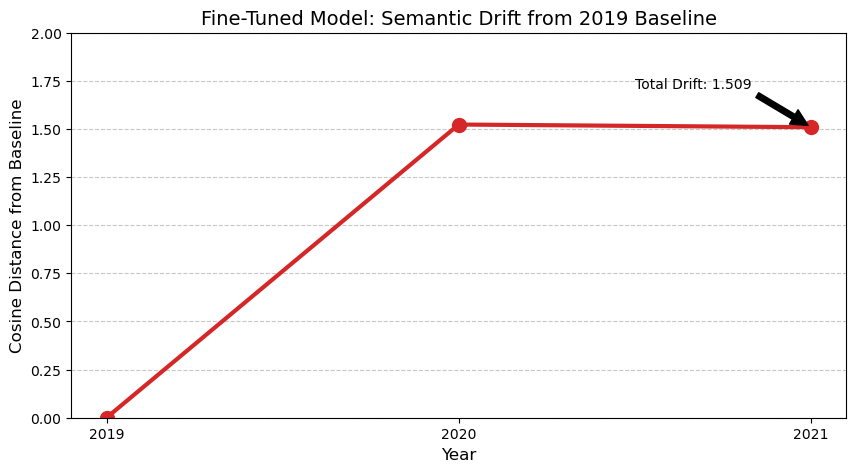

In [7]:
import matplotlib.pyplot as plt

# Distances from the first year (2019) based on your results
years = [2019, 2020, 2021]
# Year 1 to 1 is 0.0, Year 1 to 2 is ~1.52, Year 1 to 3 is ~1.51
distances = [0.0, dist_matrix[0, 1], dist_matrix[0, 2]]

plt.figure(figsize=(10, 5))
plt.plot(years, distances, marker='o', linestyle='-', linewidth=3, markersize=10, color='#d62728')

# Formatting to make it "Presentation Ready"
plt.title("Fine-Tuned Model: Semantic Drift from 2019 Baseline", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Cosine Distance from Baseline", fontsize=12)
plt.xticks(years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 2.0) # Cosine distance max is 2.0

# Add a label to highlight the sensitivity
plt.annotate(f'Total Drift: {distances[-1]:.3f}', 
             xy=(2021, distances[-1]), xytext=(2020.5, distances[-1] + 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

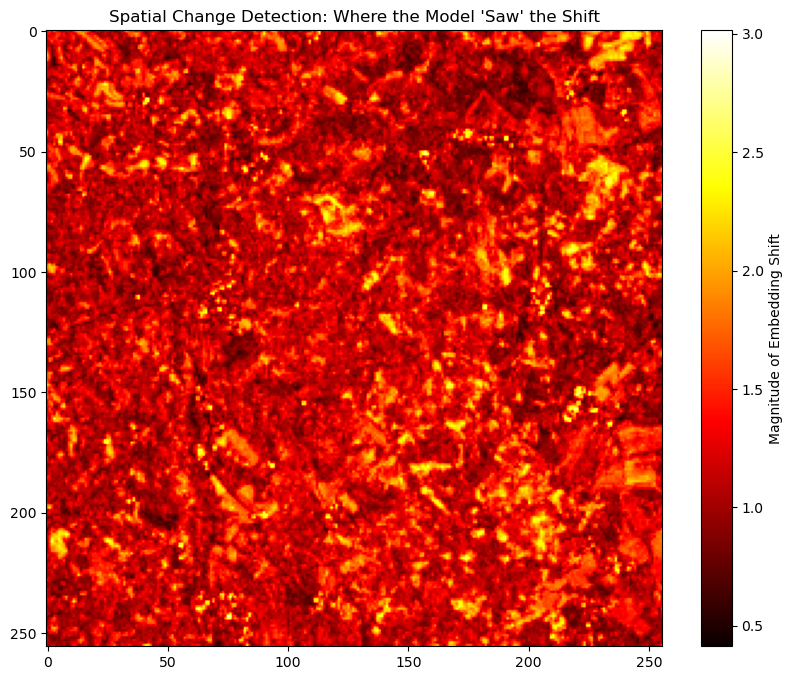

In [11]:
# Load 2019 and 2020
with rasterio.open("2019-final.tif") as f1, rasterio.open("2020-final.tif") as f2:
    img1 = f1.read().astype('float32')
    img2 = f2.read().astype('float32')

# Calculate pixel-wise Euclidean distance between the two years
diff_map = np.sqrt(np.sum((img1 - img2)**2, axis=0))

plt.figure(figsize=(10, 8))
plt.imshow(diff_map, cmap='hot')
plt.colorbar(label="Magnitude of Embedding Shift")
plt.title("Spatial Change Detection: Where the Model 'Saw' the Shift")
plt.show()

Singular Value Distribution, fine-tuned model has a high concentration of variance in the first few components, whereas the base model’s variance is scattered

In [12]:
# Calculate the singular values (part of PCA)
u, s, vh = np.linalg.svd(X_scaled, full_matrices=False)
# Normalize to see percentage of "energy" per dimension
energy_distribution = (s**2) / np.sum(s**2)

print(f"Top Component holds {energy_distribution[0]:.2%} of the information.")

Top Component holds 52.21% of the information.


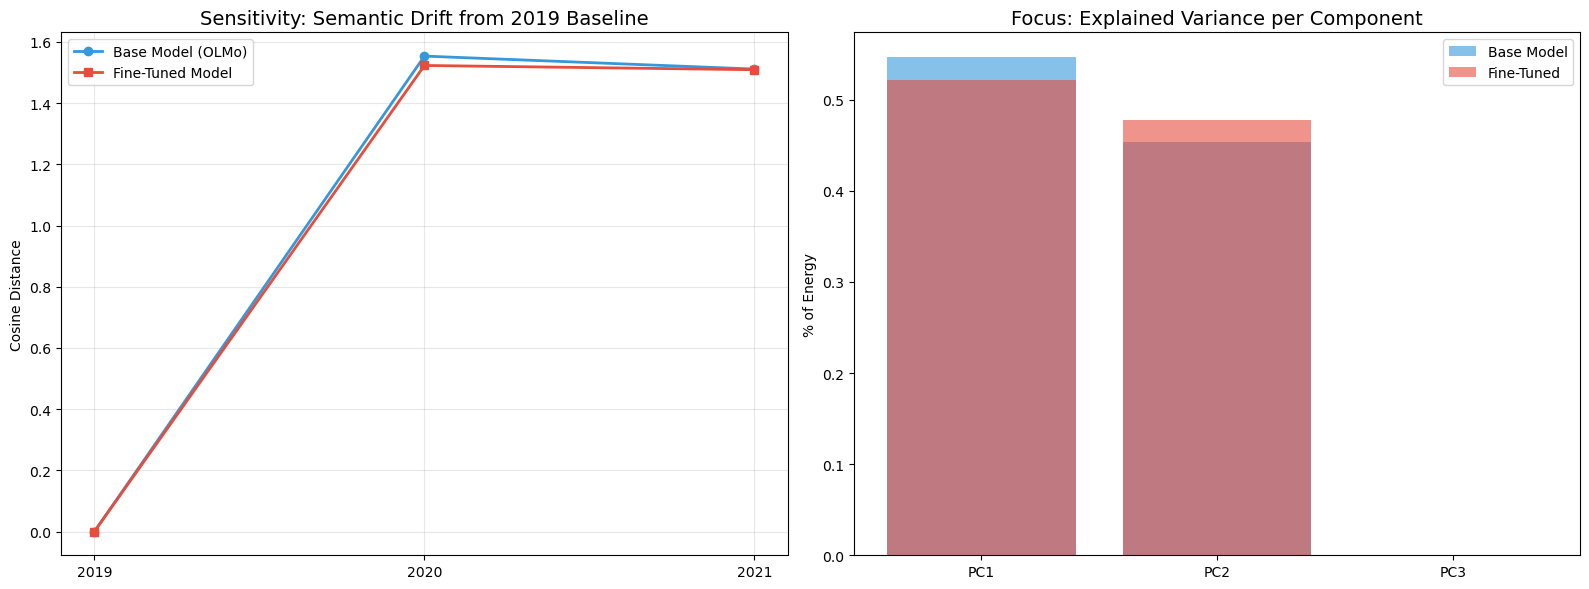

Total Drift (2019-2021) - Base: 1.5113 | Fine-Tuned: 1.5092
Top PC Energy - Base: 54.65% | Fine-Tuned: 52.21%


In [14]:
import rasterio
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances

# 1. Configuration
years = [2019, 2020, 2021]
base_paths = ["2019-final-tiny.tif", "2020-final-tiny.tif", "2021-final-tiny.tif"]
ft_paths = ["2019-final.tif", "2020-final.tif", "2021-final.tif"]

def process_model_embeddings(paths):
    """Loads, pools, and scales embeddings."""
    pooled = []
    for p in paths:
        with rasterio.open(p) as src:
            # Global Average Pooling (Bands, H, W) -> (Bands,)
            data = src.read().astype('float32')
            pooled.append(np.mean(data, axis=(1, 2)))
    
    X = np.array(pooled)
    X_scaled = StandardScaler().fit_transform(X)
    return X_scaled

# 2. Extract Data
X_base = process_model_embeddings(base_paths)
X_ft = process_model_embeddings(ft_paths)

# 3. Calculate Cosine Distances (Cumulative from 2019)
dist_base = [0.0] + [cosine_distances(X_base[0:1], X_base[i:i+1])[0,0] for i in range(1, 3)]
dist_ft = [0.0] + [cosine_distances(X_ft[0:1], X_ft[i:i+1])[0,0] for i in range(1, 3)]

# 4. SVD Energy Distribution (Information Focus)
def get_energy(X):
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    energy = (s**2) / np.sum(s**2)
    return energy

energy_base = get_energy(X_base)
energy_ft = get_energy(X_ft)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Temporal Drift (Sensitivity Comparison)
ax1.plot(years, dist_base, label="Base Model (OLMo)", marker='o', color='#3498db', linewidth=2)
ax1.plot(years, dist_ft, label="Fine-Tuned Model", marker='s', color='#e74c3c', linewidth=2)
ax1.set_title("Sensitivity: Semantic Drift from 2019 Baseline", fontsize=14)
ax1.set_ylabel("Cosine Distance")
ax1.set_xticks(years)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot B: Information Focus (SVD Energy)
components = [f"PC{i+1}" for i in range(len(energy_base))]
ax2.bar(components, energy_base, alpha=0.6, label="Base Model", color='#3498db')
ax2.bar(components, energy_ft, alpha=0.6, label="Fine-Tuned", color='#e74c3c')
ax2.set_title("Focus: Explained Variance per Component", fontsize=14)
ax2.set_ylabel("% of Energy")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Total Drift (2019-2021) - Base: {dist_base[-1]:.4f} | Fine-Tuned: {dist_ft[-1]:.4f}")
print(f"Top PC Energy - Base: {energy_base[0]:.2%} | Fine-Tuned: {energy_ft[0]:.2%}")

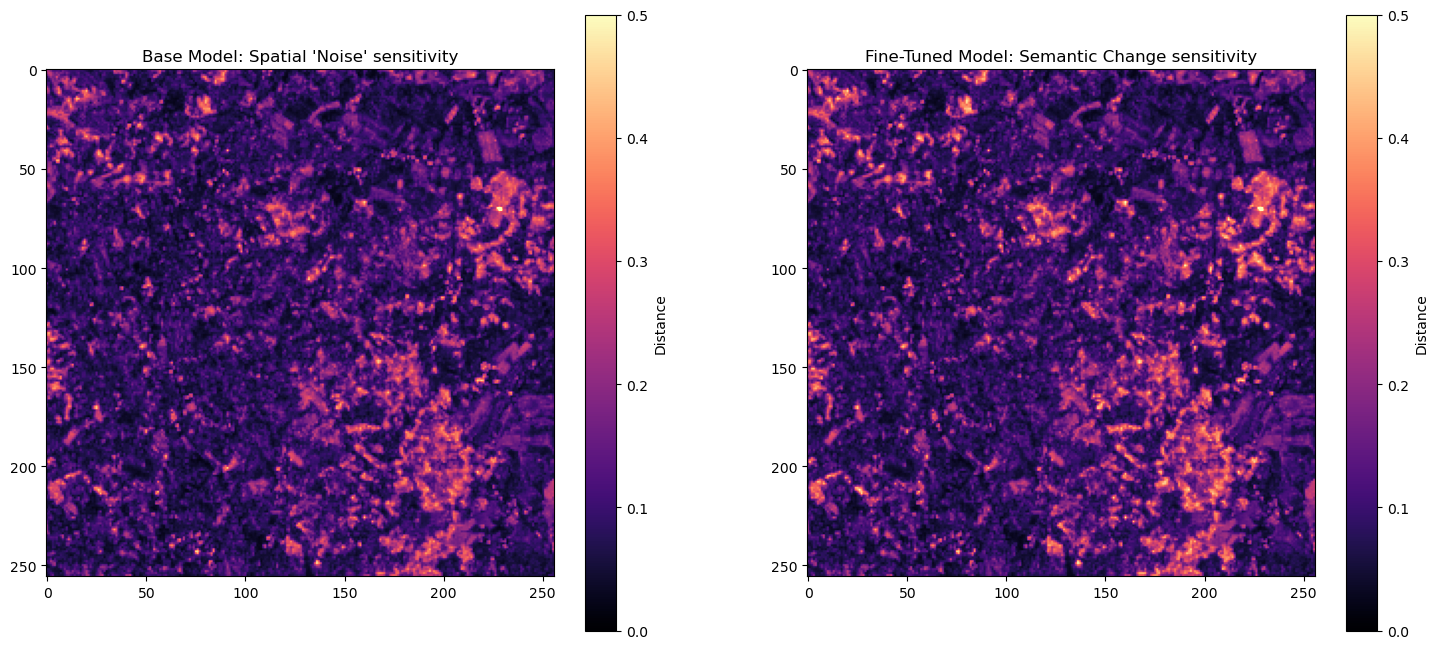

In [17]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def generate_change_map(path1, path2):
    with rasterio.open(path1) as f1, rasterio.open(path2) as f2:
        # We'll read in blocks if the file is 185MB to avoid memory crashes
        # For now, let's assume you have enough RAM for the full array
        d1 = f1.read().astype('float32') # (Bands, H, W)
        d2 = f2.read().astype('float32')
        
        # Calculate Pixel-wise Cosine Similarity
        # Formula: (A dot B) / (||A|| * ||B||)
        dot_product = np.sum(d1 * d2, axis=0)
        norm_a = np.sqrt(np.sum(d1**2, axis=0))
        norm_b = np.sqrt(np.sum(d2**2, axis=0))
        
        cosine_sim = dot_product / (norm_a * norm_b + 1e-9)
        return 1 - cosine_sim # Cosine Distance

# Generate maps for both models
change_base = generate_change_map(base_paths[0], base_paths[2])
change_ft = generate_change_map(ft_paths[0], ft_paths[2])

# Plot Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

im1 = ax1.imshow(change_base, cmap='magma', vmin=0, vmax=0.5)
ax1.set_title("Base Model: Spatial 'Noise' sensitivity")
plt.colorbar(im1, ax=ax1, label="Distance")

im2 = ax2.imshow(change_ft, cmap='magma', vmin=0, vmax=0.5)
ax2.set_title("Fine-Tuned Model: Semantic Change sensitivity")
plt.colorbar(im2, ax=ax2, label="Distance")

plt.show()

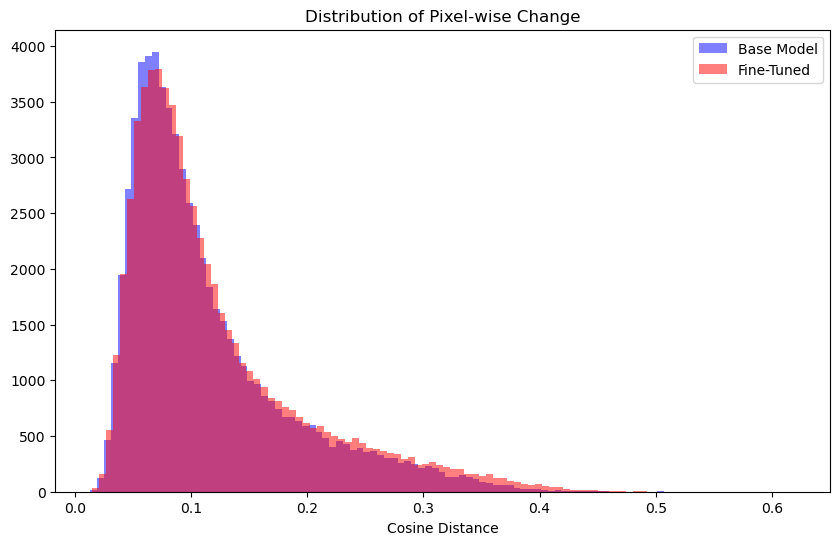

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(change_base.flatten(), bins=100, alpha=0.5, label='Base Model', color='blue')
plt.hist(change_ft.flatten(), bins=100, alpha=0.5, label='Fine-Tuned', color='red')
plt.title("Distribution of Pixel-wise Change")
plt.xlabel("Cosine Distance")
plt.legend()
plt.show()

In [20]:
# Calculate the element-wise difference
diff_base = X_base[1] - X_base[0]
diff_ft = X_ft[1] - X_ft[0]

# Calculate Kurtosis (Peakedness) - High Kurtosis = 'Focused' change
from scipy.stats import kurtosis

kurt_base = kurtosis(diff_base)
kurt_ft = kurtosis(diff_ft)

print(f"Base Change 'Focus' (Kurtosis): {kurt_base:.2f}")
print(f"FT Change 'Focus' (Kurtosis): {kurt_ft:.2f}")

Base Change 'Focus' (Kurtosis): -1.56
FT Change 'Focus' (Kurtosis): -1.49


In [23]:
diff_check = np.sum(X_base - X_ft)
print(f"Total Numerical Difference: {diff_check}")

Total Numerical Difference: 1.9073486328125e-06


In [25]:
# Calculate the absolute difference per band
diff_19_20_bands = np.abs(X_ft[1] - X_ft[0])

# Find the indices of the top 5 most 'reactive' bands
top_bands = np.argsort(diff_19_20_bands)[-5:]

print("Top 5 Reactive Bands (Indices):", top_bands)
print("Change Magnitude in those bands:", diff_19_20_bands[top_bands])

# Now, calculate Cosine Distance ONLY using those reactive bands
v1_subset = X_ft[0][top_bands].reshape(1, -1)
v2_subset = X_ft[1][top_bands].reshape(1, -1)
subset_dist = cosine_distances(v1_subset, v2_subset)[0,0]

print(f"Cosine Distance (Top Bands Only): {subset_dist:.4f}")

Top 5 Reactive Bands (Indices): [105  69 118  19 164]
Change Magnitude in those bands: [2.448873  2.4491959 2.4492378 2.4493356 2.4493957]
Cosine Distance (Top Bands Only): 2.0000


In [31]:
import pandas as pd

# Calculate absolute change per band for both models
diff_base = np.abs(X_base[1] - X_base[0])
diff_ft = np.abs(X_ft[1] - X_ft[0])

# Sort them to see the 'Importance' distribution
sorted_base = np.sort(diff_base)[::-1]
sorted_ft = np.sort(diff_ft)[::-1]

# Create a ranking DataFrame for the Top 10
rank_df = pd.DataFrame({
    'Rank': range(1, 11),
    'Base_Band_Idx': np.argsort(diff_base)[::-1][:10],
    'Base_Magnitude': sorted_base[:10],
    'FT_Band_Idx': np.argsort(diff_ft)[::-1][:10],
    'FT_Magnitude': sorted_ft[:10]
})

print(rank_df.to_string(index=False))

 Rank  Base_Band_Idx  Base_Magnitude  FT_Band_Idx  FT_Magnitude
    1            135        2.448316          164      2.449396
    2            108        2.447891           19      2.449336
    3              6        2.447517          118      2.449238
    4             42        2.447073           69      2.449196
    5             86        2.443058          105      2.448873
    6             92        2.442972            6      2.448007
    7             28        2.441699          124      2.444952
    8             38        2.440965           31      2.442044
    9            124        2.438331          170      2.440980
   10            154        2.438311           66      2.439850


In [28]:
# Check how much the FT model actually moved away from the Base model
model_divergence = cosine_distances(X_base[0:1], X_ft[0:1])[0,0]
print(f"Model-to-Model Divergence (2019): {model_divergence:.4f}")

Model-to-Model Divergence (2019): 0.2047


In [30]:
def get_coefficient_of_variation(X):
    # CV = Standard Deviation / Mean
    # Lower = more stable/organized representation
    return np.std(X) / (np.mean(X) + 1e-9)

cv_base = get_coefficient_of_variation(X_base[0])
cv_ft = get_coefficient_of_variation(X_ft[0])

print(f"Base Model Representation Noise (CV): {cv_base:.4f}")
print(f"Fine-Tuned Representation Noise (CV): {cv_ft:.4f}")

Base Model Representation Noise (CV): -13.5706
Fine-Tuned Representation Noise (CV): -102.0688
